In [1]:

import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df =pd.read_csv('C:/Users/pinki/OneDrive/Desktop/Machine_learning_indetails/dataset/movie_review.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
def clean_text(text):
    text = str(text)   # convert to string
    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # keep only letters and spaces
    text = re.sub(r'[^A-Za-z\s]', '', text)
    return text

In [4]:
df['review'] = df['review'].apply(clean_text)

In [5]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production The filming tech...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically theres a family where a little boy J...,negative
4,Petter Matteis Love in the Time of Money is a ...,positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,Bad plot bad dialogue bad acting idiotic direc...,negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,Im going to have to disagree with the previous...,negative


In [6]:
x = df['review']
y = df['sentiment']


In [7]:
# import re
# text = "pinki is my name so she does't a boy"
# text = re.sub(r"'", "", text)

In [8]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=42)



In [9]:
ignore_words = {'I','not','do','like'}
custom_stop_words = list(set(ENGLISH_STOP_WORDS)-ignore_words)

In [10]:

tfidf = TfidfVectorizer(
    lowercase = True,
    stop_words=custom_stop_words,
    ngram_range =(1,2))

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
model = MultinomialNB(alpha = 0.1)


In [ ]:
model.fit(X_train_tfidf,Y_train)
y_pred = model.predict(X_test_tfidf) 

In [ ]:
y_pred

array(['positive', 'positive', 'negative', ..., 'negative', 'negative',
       'negative'], shape=(10000,), dtype='<U8')

In [ ]:
cr = classification_report(Y_test, y_pred)
cm = confusion_matrix(Y_test, y_pred)

In [ ]:
print(cr)

              precision    recall  f1-score   support

    negative       0.88      0.89      0.89      4961
    positive       0.89      0.88      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
print(cm)

[[4431  530]
 [ 610 4429]]


<Axes: >

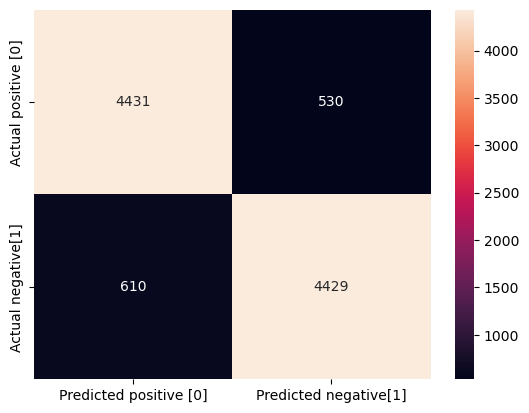

In [ ]:
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=['Predicted positive [0]', 'Predicted negative[1]'],
           yticklabels=['Actual positive [0]', 'Actual negative[1]'])

In [ ]:
def predict_data(text):  
    clean_data = clean_text(text)
    clean_data_tfidf = tfidf.fit_transform([clean_data])
    data_pred = model.predict(clean_data_tfidf)[0]
    return data_pred

In [ ]:
review= input('enter your movie here:') 
if predict_data(review) == 'negative':
    predict_data(review)
    print('\negative review')
else:
    print('\positive review')    




ValueError: X has 1 features, but MultinomialNB is expecting 2779112 features as input.